In [38]:
import numpy as np
import orix
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
from copy import deepcopy
import matplotlib.patches as mpatches
import matplotlib.path as mpath
import matplotlib.pyplot as plt

import orix.plot

from utils.quat_ops import to_scalar_first, format_quaternions, project_to_fundametal_region, normalize_quaternions, enforce_hemisphere

from visualization.ipf_render import render_ipf_image

fp = "/data/warren/materials/materials_data_mount/x_slice_0000.npy"

q_arr = np.load(fp, mmap_mode="r")

In [39]:
q_arr = np.load(fp, mmap_mode="r")
q_arr_scalar_first = to_scalar_first(q_arr)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from orix import sampling
from orix.plot import register_projections
from orix.quaternion import symmetry
from orix.vector import Vector3d

register_projections()  # Register our custom Matplotlib projections

# Sample rotations with an average misorientation
res = 2
pg = symmetry.Oh  # 4/mmm

R = sampling.get_sample_reduced_fundamental(res, point_group=pg)
print(np.allclose(R.to_euler()[1:, 0], 0))




True


In [4]:
v1 = R * Vector3d.zvector()

v2 = sampling.sample_S2(res)
v2 = v2[v2 <= pg.fundamental_sector]

# Only equivalent for the same S2 sampling method
print(np.allclose(v1.data, v2.data))
print(v1)
print(v2)

True
Vector3d (300,)
[[0.     0.     1.    ]
 [0.0341 0.     0.9994]
 [0.0682 0.     0.9977]
 [0.1023 0.     0.9948]
 [0.1362 0.     0.9907]
 [0.1699 0.     0.9855]
 [0.2035 0.     0.9791]
 [0.2368 0.     0.9716]
 [0.2698 0.     0.9629]
 [0.3025 0.     0.9531]
 [0.3349 0.     0.9423]
 [0.3669 0.     0.9303]
 [0.3984 0.     0.9172]
 [0.4295 0.     0.9031]
 [0.4601 0.     0.8879]
 [0.4901 0.     0.8717]
 [0.5196 0.     0.8544]
 [0.5485 0.     0.8362]
 [0.5767 0.     0.817 ]
 [0.6042 0.     0.7968]
 [0.6311 0.     0.7757]
 [0.6572 0.     0.7537]
 [0.6826 0.     0.7308]
 [0.0341 0.0341 0.9988]
 [0.0682 0.0341 0.9971]
 [0.1022 0.034  0.9942]
 [0.1361 0.0338 0.9901]
 [0.1698 0.0336 0.9849]
 [0.2033 0.0334 0.9785]
 [0.2366 0.0332 0.971 ]
 [0.2697 0.0329 0.9624]
 [0.3024 0.0325 0.9526]
 [0.3347 0.0322 0.9418]
 [0.3667 0.0318 0.9298]
 [0.3982 0.0313 0.9168]
 [0.4293 0.0308 0.9026]
 [0.4599 0.0303 0.8875]
 [0.4899 0.0298 0.8713]
 [0.5194 0.0292 0.8541]
 [0.5482 0.0286 0.8358]
 [0.5765 0.0279 0.8

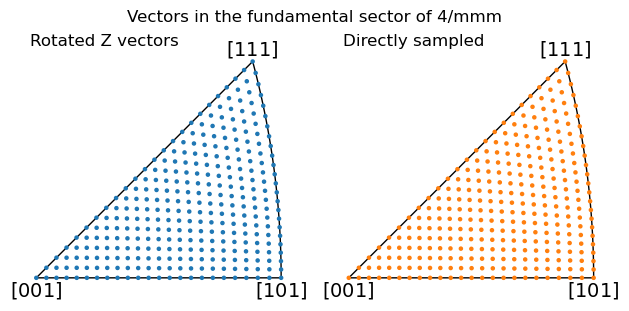

In [ ]:
fig, (ax0, ax1) = plt.subplots(
    ncols=2, subplot_kw={"projection": "ipf", "symmetry": pg}, layout="tight"
)
ax0.scatter(v1, s=5)
ax1.scatter(v2, c="C1", s=5)
ax0.set_title("Rotated Z vectors", loc="left")
ax1.set_title("Directly sampled", loc="left")
_ = fig.suptitle("Vectors in the fundamental sector of m-3m", y=0.8)

In [40]:
# Quaternion formatting (normalize + hemisphere + FZ)
q_cf = format_quaternions(
    q_arr_scalar_first,
    normalize=True,
    hemisphere=True,
    reduce_fz=True,
    sym="Oh",
    to_quat_first=False,
)

In [41]:
q_cf.shape

(420, 549, 4)

In [ ]:
def plot_fz_ipf_helper(ax, q_flat, sym_class, ref_dir="Z", tol_deg=0.5, label=""):
    sym = getattr(symmetry, sym_class) if isinstance(sym_class, str) else sym_class

    # Normalize input quaternions (wxyz)
    q_np = np.asarray(q_flat, dtype=np.float64)
    q_np = normalize_quaternions(q_np, axis=-1)
    q_np = enforce_hemisphere(q_np, scalar_first=True)

    # Proper symmetry operators (24) for quaternion FZ reduction
    qCS_all = np.asarray(sym.data, dtype=np.float64)
    qCS = qCS_all[:24] if qCS_all.shape[0] == 48 else qCS_all
    qCS = qCS / np.linalg.norm(qCS, axis=-1, keepdims=True)

    # Ensure identity is first
    id_idx = int(np.argmin(np.linalg.norm(qCS - np.array([1.0, 0.0, 0.0, 0.0]), axis=1)))
    if id_idx != 0:
        qCS[[0, id_idx]] = qCS[[id_idx, 0]]

    # Quaternion-space FZ reduction (passive/Bunge: s^-1 * q)
    q_fz = project_to_fundametal_region(q_np, qCS, q_ref_b=None)
    ori_fz = Orientation(q_fz, symmetry=sym)

    ref_map = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}
    v_ref = ref_map[ref_dir.upper()]

    # Raw vectors from reduced orientations
    v_raw = (ori_fz) * v_ref

    # Important: reduce vectors to IPF fundamental sector (red triangle)
    # Map vectors to IPF sector
    v_plot = v_raw.in_fundamental_sector(sym)

    # Detect which vectors were outside sector before mapping
    # (if mapping changed direction by > tol_deg, it was outside)
    raw_xyz = np.asarray(v_raw.data).reshape(-1, 3)
    map_xyz = np.asarray(v_plot.data).reshape(-1, 3)

    dots = np.einsum("ij,ij->i", raw_xyz, map_xyz)
    dots = np.clip(dots, -1.0, 1.0)
    ang_deg = np.degrees(np.arccos(dots))

    outside_mask = ang_deg > max(tol_deg, 1e-6)
    frac_outside = 100.0 * outside_mask.mean()

    print(f"{label} - Outside IPF sector: {frac_outside:.2f}% ({outside_mask.sum()} out of {len(q_fz)})")
    print(f"  - Inside sector originally: {len(q_fz) - outside_mask.sum()} quaternions")

    ckey = orix.plot.IPFColorKeyTSL(sym.laue)
    ckey.direction = v_ref
    colors = ckey.orientation2color(ori_fz)

    ax.set_title(f"{label} — Outside IPF sector before vector reduction: {frac_outside:.2f}%", pad=20, fontsize=11)

    # Inside sector originally
    ax.scatter(
        v_plot[~outside_mask],
        c=colors[~outside_mask],
        s=100,
        alpha=1.0,
        marker="*",
        edgecolors="none",
        label="Inside sector originally",
    )

    # Mapped into sector
    if np.any(outside_mask):
        # ax.scatter(
        #     v_plot[outside_mask],
        #     c=colors[outside_mask],
        #     s=20,
        #     alpha=0.95,
        #     marker="p",
        #     edgecolors=None,
        #     linewidths=0.4,
        #     label="Mapped into sector",
        # )
        ax.scatter(
            v_raw[outside_mask],
            c=colors[outside_mask],
            s=50,
            alpha=1.0,
            marker="o",
            edgecolors=None,
            linewidths=0.4,
            label="Outside before mapping",
        )

    # Symmetry guide circles
    v4fold = Vector3d([[0, 0, 1], [1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0]])
    v3fold = Vector3d([[1, 1, 1], [1, -1, 1], [-1, -1, 1], [-1, 1, 1]])
    v2fold = Vector3d([[1, 0, 1], [0, 1, 1], [-1, 0, 1], [0, -1, 1], [1, 1, 0], [-1, -1, 0], [-1, 1, 0], [1, -1, 0]])
    ax.draw_circle(v4fold, color="black")
    ax.draw_circle(v3fold, color="black")
    ax.draw_circle(v2fold, color="black")

    # Draw red IPF sector boundary
    sector = sym.fundamental_sector
    original_pole = deepcopy(sector._pole)
    sector._pole = ax.pole
    edges = sector.edges
    sector._pole = original_pole
    x, y, _ = ax._pretransform_input((edges,))
    patch = mpatches.PathPatch(
        mpath.Path(np.column_stack([x, y]), closed=True),
        facecolor="none",
        edgecolor="red",
        linewidth=1.5,
        alpha=0.9,
        zorder=5,
    )
    ax.add_patch(patch)

    ax.set_labels("RD", "TD", None)
    ax.show_hemisphere_label()
    ax.legend(loc="upper right", fontsize=8, markerscale=1.1)

    return frac_outside, outside_mask


Data - Outside IPF sector: 82.02% (189126 out of 230580)
  - Inside sector originally: 41454 quaternions


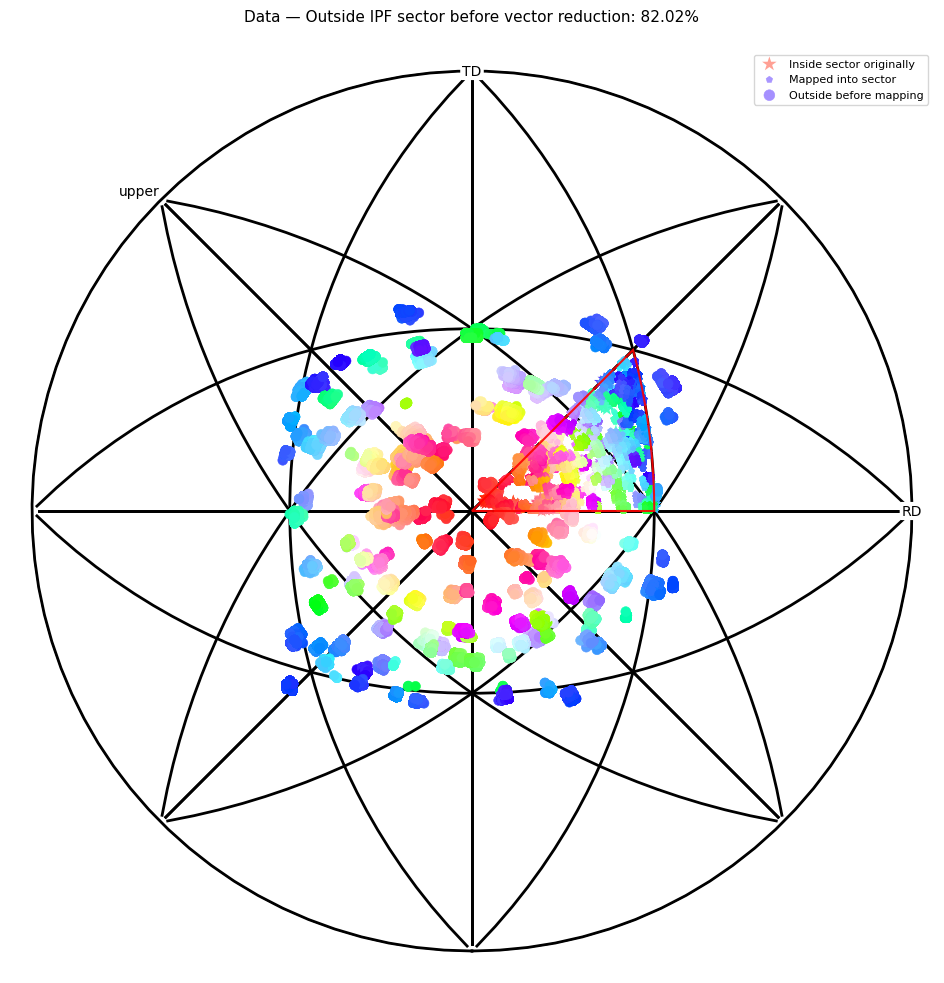

In [47]:

data = q_cf

# expect last axis size 4
if data.ndim < 1 or data.shape[-1] != 4:
    raise SystemExit("Input must have last axis size 4 (w,x,y,z)")

q_flat = data.reshape(-1, 4)

fig, ax = plt.subplots(subplot_kw={"projection": "stereographic"}, figsize=(12, 12))
fz_frac, op_map = plot_fz_ipf_helper(ax, q_flat, sym_class="Oh", ref_dir="Z", tol_deg=0.5, label="Data")



In [ ]:
from utils.quat_ops import get_dummy_quats


resolution_deg = 7.0
ref_dir = "Z"
tol_deg = 0.5
sym = symmetry.Oh


data = get_dummy_quats(resolution_deg=resolution_deg)

# expect last axis size 4
if data.ndim < 1 or data.shape[-1] != 4:
    raise SystemExit("Input must have last axis size 4 (w,x,y,z)")

q_flat = data.reshape(-1, 4)

# Normalize input quaternions (wxyz)
q_np = np.asarray(q_flat, dtype=np.float64)
q_np = normalize_quaternions(q_np, axis=-1)
q_np = enforce_hemisphere(q_np, scalar_first=True)

# Proper symmetry operators (24) for quaternion FZ reduction
qCS_all = np.asarray(sym.data, dtype=np.float64)
qCS = qCS_all[:24] if qCS_all.shape[0] == 48 else qCS_all
qCS = qCS / np.linalg.norm(qCS, axis=-1, keepdims=True)

# Ensure identity is first
id_idx = int(np.argmin(np.linalg.norm(qCS - np.array([1.0, 0.0, 0.0, 0.0]), axis=1)))
if id_idx != 0:
    qCS[[0, id_idx]] = qCS[[id_idx, 0]]

# Quaternion-space FZ reduction (passive/Bunge: s^-1 * q)
q_fz = project_to_fundametal_region(q_np, qCS, q_ref_b=None)
ori_fz = Orientation(q_fz, symmetry=sym)

ref_map = {"X": Vector3d.xvector(), "Y": Vector3d.yvector(), "Z": Vector3d.zvector()}
v_ref = ref_map[ref_dir.upper()]

# 1) vectors before IPF-sector mapping
v_before = ori_fz * v_ref

# 2) vectors after IPF-sector mapping
v_after = v_before.in_fundamental_sector(sym)

# Detect vectors that were outside the sector before mapping
raw_xyz = np.asarray(v_before.data).reshape(-1, 3)
map_xyz = np.asarray(v_after.data).reshape(-1, 3)
dots = np.einsum("ij,ij->i", raw_xyz, map_xyz)
dots = np.clip(dots, -1.0, 1.0)
ang_deg = np.degrees(np.arccos(dots))
outside_mask = ang_deg > max(tol_deg, 1e-6)
fz_frac = 100.0 * outside_mask.mean()

print(f"Outside IPF sector before mapping: {fz_frac:.2f}% ({outside_mask.sum()} out of {len(q_fz)})")

ckey = orix.plot.IPFColorKeyTSL(sym.laue)
ckey.direction = v_ref
colors = ckey.orientation2color(ori_fz)


def decorate_stereo_axis(ax, title):
    # Symmetry guide circles
    v4fold = Vector3d([[0, 0, 1], [1, 0, 0], [-1, 0, 0], [0, 1, 0], [0, -1, 0]])
    v3fold = Vector3d([[1, 1, 1], [1, -1, 1], [-1, -1, 1], [-1, 1, 1]])
    v2fold = Vector3d([
        [1, 0, 1], [0, 1, 1], [-1, 0, 1], [0, -1, 1],
        [1, 1, 0], [-1, -1, 0], [-1, 1, 0], [1, -1, 0],
    ])
    ax.draw_circle(v4fold, color="black")
    ax.draw_circle(v3fold, color="black")
    ax.draw_circle(v2fold, color="black")

    # Draw red IPF sector boundary
    sector = sym.fundamental_sector
    original_pole = deepcopy(sector._pole)
    sector._pole = ax.pole
    edges = sector.edges
    sector._pole = original_pole
    x, y, _ = ax._pretransform_input((edges,))
    patch = mpatches.PathPatch(
        mpath.Path(np.column_stack([x, y]), closed=True),
        facecolor="none",
        edgecolor="red",
        linewidth=1.5,
        alpha=0.9,
        zorder=5,
    )
    ax.add_patch(patch)

    ax.set_title(title, fontsize=11, pad=14)
    ax.set_labels("RD", "TD", None)
    ax.show_hemisphere_label()


fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])
ax0 = fig.add_subplot(gs[0, 0], projection="stereographic")
ax1 = fig.add_subplot(gs[0, 1], projection="stereographic")
ax2 = fig.add_subplot(gs[0, 2], projection="ipf", symmetry=sym.laue)

# Panel 1: original vectors (before sector mapping)
ax0.scatter(v_before, c=colors, s=16, alpha=0.95, edgecolors="none")
decorate_stereo_axis(ax0, f"1) Original vectors\nOutside sector: {fz_frac:.2f}%")

# Panel 2: mapped vectors (inside sector)
ax1.scatter(
    v_after[~outside_mask],
    c=colors[~outside_mask],
    s=50,
    alpha=1.0,
    marker="*",
    edgecolors="none",
    label="Inside sector originally",
)
if np.any(outside_mask):
    ax1.scatter(
        v_after[outside_mask],
        c=colors[outside_mask],
        s=16,
        alpha=0.95,
        marker="o",
        edgecolors="none",
        label="Mapped into sector",
    )

decorate_stereo_axis(ax1, "2) After IPF sector mapping")
ax1.legend(loc="upper right", fontsize=8, markerscale=1.0)

# Panel 3: IPF key
ax2.plot_ipf_color_key()
ax2.set_title(f"3) IPF key ({ref_dir.upper()})", fontsize=11, pad=14)

fig.suptitle(f"Quaternion FZ/IPF comparison (sym=Oh, resolution={resolution_deg} deg)", fontsize=13)
fig.tight_layout()



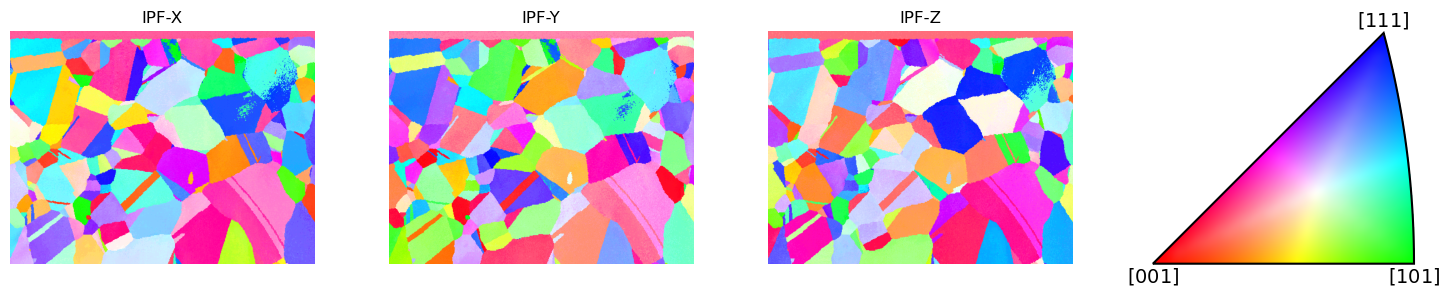

In [44]:
render_ipf_image(
    q_arr=q_arr,
    sym_class=symmetry.Oh,
    out_png=None,
    ref_dir="ALL",
    include_key=True,
    overwrite=False,
    format_input=True)

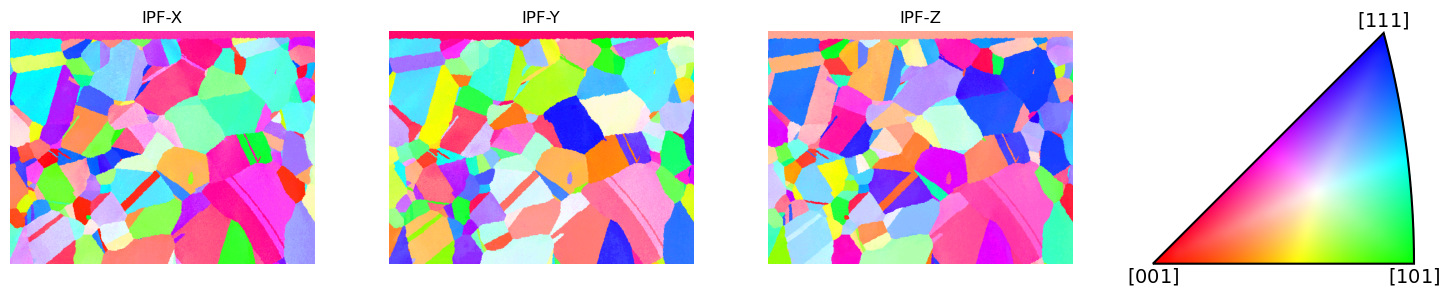

In [45]:
render_ipf_image(
    q_arr=q_arr_scalar_first,
    sym_class=symmetry.Oh,
    out_png=None,
    ref_dir="ALL",
    include_key=True,
    overwrite=False,
    format_input=True)


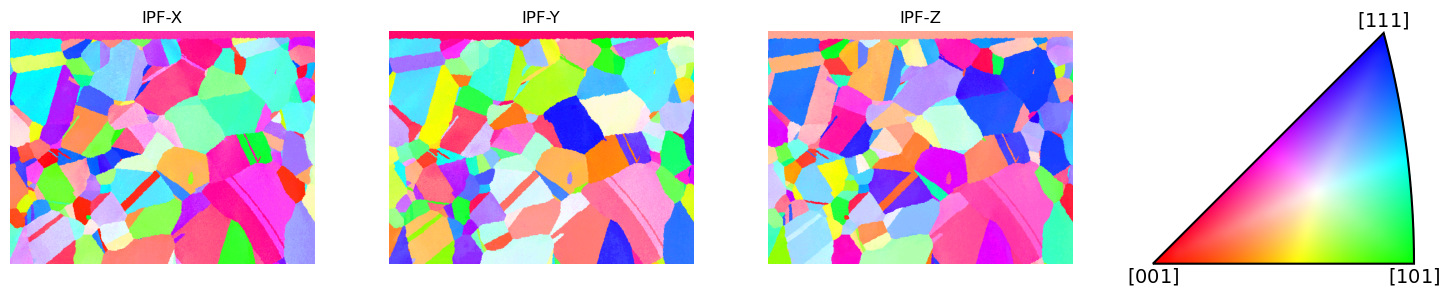

In [46]:
render_ipf_image(
    q_arr=q_cf,
    sym_class=symmetry.Oh,
    out_png=None,
    ref_dir="ALL",
    include_key=True,
    overwrite=False,
    format_input=True)
